In [1]:
# This is boilerplate code to correctly setup the settings to for notebook.
import os, sys
for root, dirs, files in os.walk(os.getcwd()):
    # print(root)

    if "pion-argon-xs-analysis" in root.split("/"):
        pypath = root.split("pion-argon-xs-analysis")[0] + "/pion-argon-xs-analysis/analysis"
        print(pypath)
        break

sys.path.insert(0, pypath)

from python.analysis.NotebookUtils import init_notebook
%init_notebook

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
env: PYTHONPATH=/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis


In [ ]:
import awkward as ak
import numpy as np
from python.analysis import cross_section, Application
from apps import cex_analysis_input
cross_section.SetPlotStyle(dpi = 100, dark = True)

In [3]:
cfg = Application.ApplicationArguments.ResolveConfig(cross_section.LoadConfiguration("/home/bhuller/work/analysis_new_selection/analysis_config_new_selection.json"))

In [4]:
ais = {k : cross_section.AnalysisInput.FromFile(v) for k, v in cfg.analysis_input.items()}

In [ ]:
tags

{'absorption': Tag(name='absorption', name_simple='abs', colour='#777777', mask=<Array [False, False, False, ..., False, False, False] type='190641 * bool'>, number=0),
 'charge_exchange': Tag(name='charge_exchange', name_simple='cex', colour='#8EBA42', mask=<Array [False, False, False, ..., False, False, False] type='190641 * bool'>, number=1),
 'pion_production': Tag(name='pion_production', name_simple='pip', colour='#988ED5', mask=<Array [True, True, False, False, ..., True, True, True] type='190641 * bool'>, number=2),
 'impurities': Tag(name='impurities', name_simple='imp', colour='#E24A33', mask=<Array [False, False, True, ..., False, False, False] type='190641 * bool'>, number=3),
 'uncategorised': Tag(name='uncategorised', name_simple='unc', colour='#000000', mask=<Array [False, False, False, ..., False, False, False] type='190641 * bool'>, number=4)}

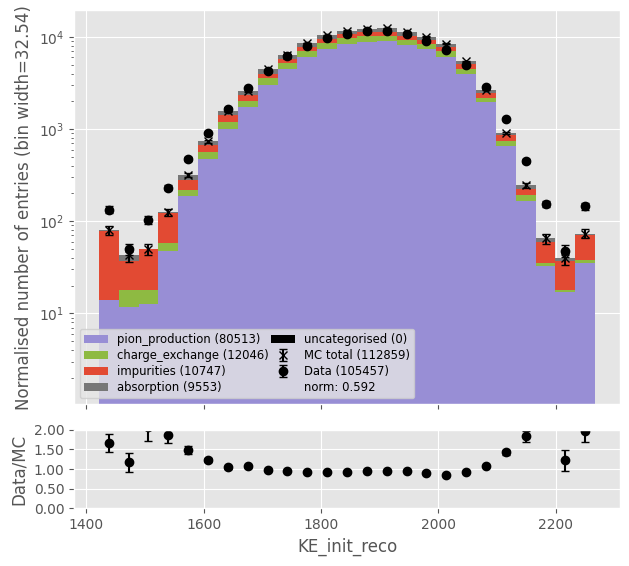

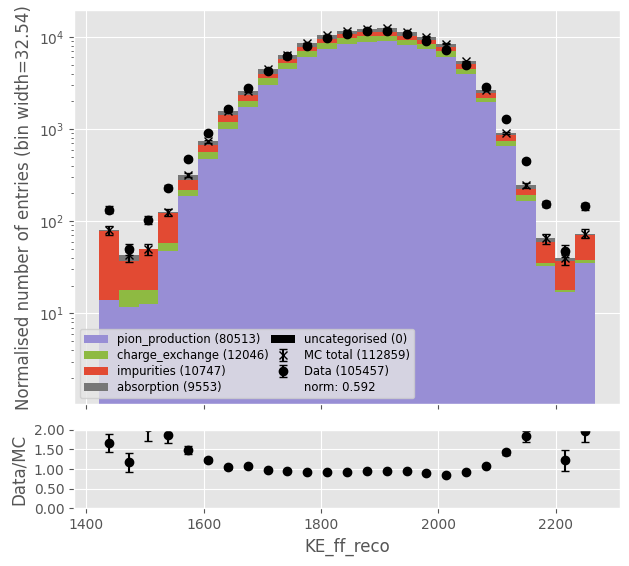

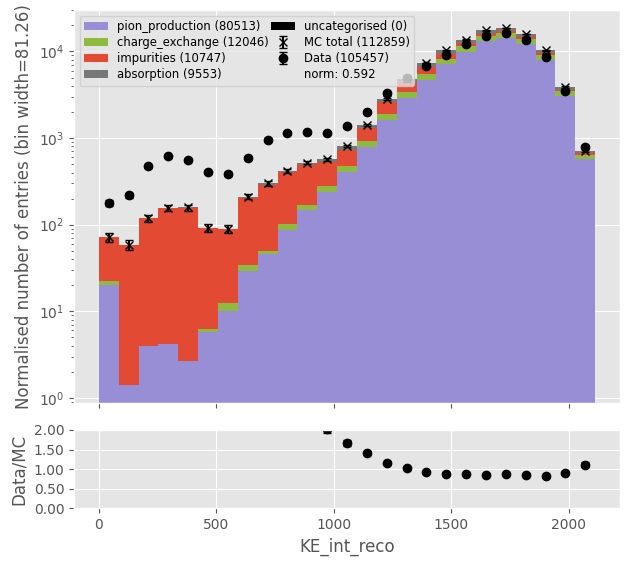

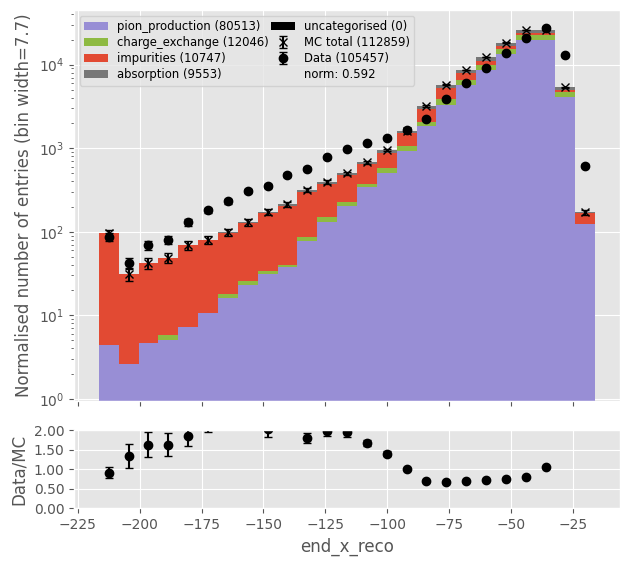

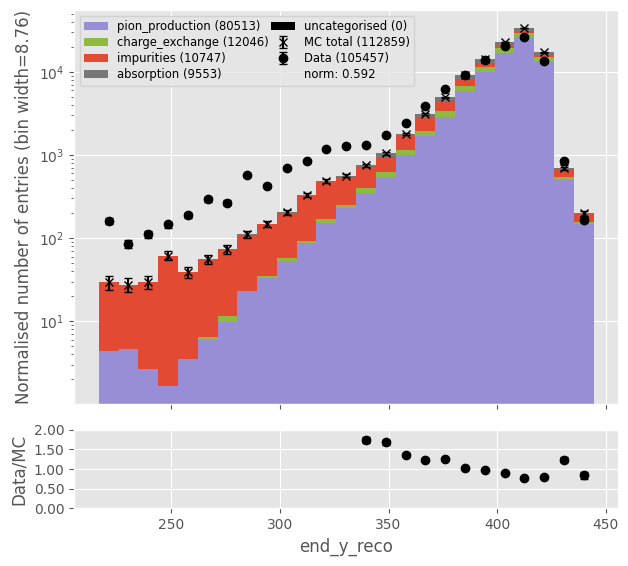

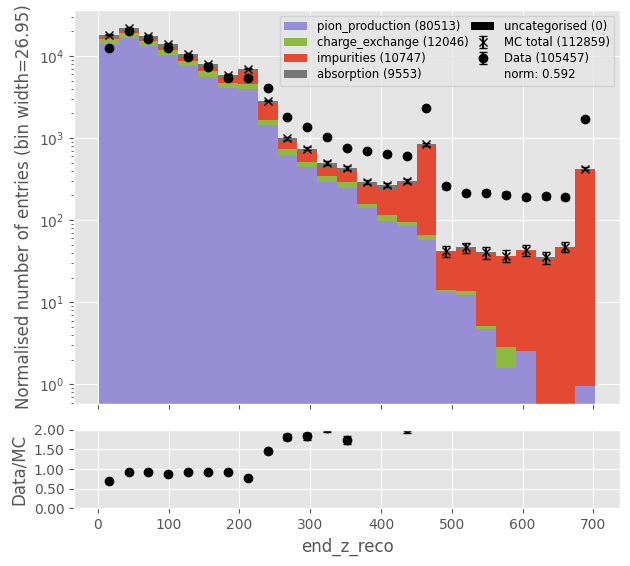

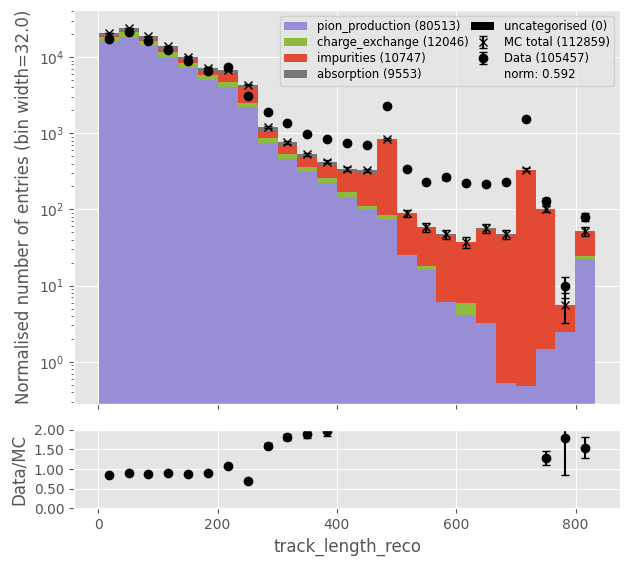

In [5]:
tags = cross_section.Tags.ExclusiveProcessTags(ais["mc"].exclusive_process)

params = [
    "KE_init_reco",
    "KE_ff_reco",
    "KE_int_reco",
    "end_x_reco",
    "end_y_reco",
    "end_z_reco",
    "track_length_reco"
]

for i in params:
    mc = getattr(ais["mc"], i)
    data = getattr(ais["data"], i)
    bounds = [np.percentile(cross_section.ak.flatten([mc, data]), 0.05), np.percentile(cross_section.ak.flatten([mc, data]), 99.95)]
    # print(bounds)
    cross_section.Plots.PlotTagged(mc, tags, 25, x_range = bounds, data2 = data, norm = cfg.norm, data_weights = ais["mc"].weights, truncate = True, x_label = i, y_scale = "log")


[
    [np.int64(7044), np.int64(472), np.int64(4684), np.int64(3937)],
    [np.int64(2152), np.int64(5990), np.int64(4886), np.int64(7320)],
    [np.int64(15674), np.int64(7253), np.int64(76925), np.int64(36150)],
    [np.int64(1802), np.int64(224), np.int64(13272), np.int64(2856)],
    [np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
]

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis/python/analysis/Plots.py:1404: RuntimeWarning: invalid value encountered in divide
  fractions = counts / np.sum(counts, axis = 1)[:, np.newaxis]


IndexError: index 4 is out of bounds for axis 0 with size 4

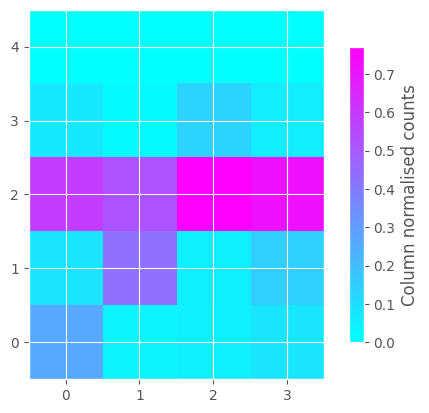

In [8]:
from apps.cex_analyse import PlotRegions
PlotRegions(ais["mc"], cross_section.Plots.PlotBook.null())